In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import spin_Jx, spin_Jy, spin_Jz, spin_coherent
from scipy.optimize import minimize, curve_fit
from joblib import Parallel, delayed
import time as t
from scipy.linalg import sqrtm, inv, eigh, expm, expm_frechet
import gc

In [2]:
#Control Hamiltonian
def H_c(phi=[], beta=1, omega=1, J=1):
    H_c = np.array([omega*(np.cos(phi[i])*J_x+np.sin(phi[i])*J_y)+ beta/(2*J) * J_z2 for i in range(len(phi))])
    return H_c
#Parameters
rng = np.random.default_rng(1)
J = 4.5
dim = int(2*J+1)
t_steps = 6000
delta_t = 0.001
#beta = 1
omega = 10
w_true = [0, 0, 0.1] #True parameter values
#w_true = rng.normal(0, 0.1, 3) #True parameter values
w_init = [0, 0, 0] #Initial guess for parameters
batch_size = 50 #Number of parallel optimizations
iter = 500 #Total number of optimization iterations
beta_array = np.array([0.1]) #Array of beta values for different runs
sn_sd = 1/np.sqrt(100000 * delta_t) #Standard deviation of shot noise
gtol = 1e-5 #Gradient tolerance for optimization convergence
theta_scs = np.pi/2 #Initial spin coherent state parameters
phi_scs = 0 #Initial spin coherent state parameters
J_x = spin_Jx(J).full()
J_y = spin_Jy(J).full()
J_z = spin_Jz(J).full()
J_z2 = J_z @ J_z
obs_0 = J_y #Initial observable

if np.array_equal(obs_0, J_x):
    obs_0_string = 'J_x'
elif np.array_equal(obs_0, J_y):
    obs_0_string = 'J_y'
elif np.array_equal(obs_0, J_z):
    obs_0_string = 'J_z'
else:
    obs_0_string = 'unknown'


evolution_time = [t_step * delta_t for t_step in range(t_steps+1)]
#in_state = (1/np.sqrt(2))*(spin_coherent(J, theta_scs, phi_scs, type = 'dm')+ spin_coherent(J, theta_scs, phi_scs + np.pi, type = 'dm')).full()
in_state = spin_coherent(J, theta_scs, phi_scs, type = 'dm').full()
def commutator(A, B):
   """Compute the commutator [A, B] = AB - BA."""
   return A @ B - B @ A

def expect(obs, state):
    """Compute the expectation value of an observable."""
    return np.real(np.trace(obs @ state))

def fidelity(rho, sigma):
    # Compute sqrt(rho)
    sqrt_rho = sqrtm(rho)
    # Compute sqrt_rho * sigma * sqrt_rho
    inner = sqrt_rho @ sigma @ sqrt_rho
    # Compute sqrt of the inner matrix
    sqrt_inner = sqrtm(inner)
    # Take the trace and square the result
    fidelity_value = np.real(np.trace(sqrt_inner)) ** 2
    return fidelity_value

def compute_expectations_concurrent_then_sensing(w, t_split):
    H_w = w[0]*J_x + w[1]*J_y + w[2]*J_z
    U_w = expm(-1j * delta_t * H_w)
    U_w_dagger = U_w.conj().T

    # Frechet derivatives
    del_U_w_x = expm_frechet(-1j * delta_t * H_w, -1j * delta_t * J_x, compute_expm=False)
    del_U_w_y = expm_frechet(-1j * delta_t * H_w, -1j * delta_t * J_y, compute_expm=False)
    del_U_w_z = expm_frechet(-1j * delta_t * H_w, -1j * delta_t * J_z, compute_expm=False)

    del_U_w_dagger_x = expm_frechet(1j * delta_t * H_w, 1j * delta_t * J_x, compute_expm=False)
    del_U_w_dagger_y = expm_frechet(1j * delta_t * H_w, 1j * delta_t * J_y, compute_expm=False)
    del_U_w_dagger_z = expm_frechet(1j * delta_t * H_w, 1j * delta_t * J_z, compute_expm=False)

    obs_array = [None]*(t_steps+1)
    obs_array[0] = obs_0

    del_obs_x = np.zeros_like(obs_0)
    del_obs_y = np.zeros_like(obs_0)
    del_obs_z = np.zeros_like(obs_0)

    del_expect_x = np.zeros(t_steps+1)
    del_expect_y = np.zeros(t_steps+1)
    del_expect_z = np.zeros(t_steps+1)

    # Heisenberg evolution
    for i in range(t_steps):
        obs = obs_array[i]

        if i < t_split:
            # control + sensing
            obs = (U_w_dagger @ U_c_dagger_array[i]) @ obs @ (U_c_array[i] @ U_w)

            del_obs_x = (
                del_U_w_dagger_x @ U_c_dagger_array[i] @ obs_array[i] @ U_c_array[i] @ U_w +
                U_w_dagger @ U_c_dagger_array[i] @ obs_array[i] @ U_c_array[i] @ del_U_w_x +
                U_w_dagger @ U_c_dagger_array[i] @ del_obs_x @ U_c_array[i] @ U_w
            )

            del_obs_y = (
                del_U_w_dagger_y @ U_c_dagger_array[i] @ obs_array[i] @ U_c_array[i] @ U_w +
                U_w_dagger @ U_c_dagger_array[i] @ obs_array[i] @ U_c_array[i] @ del_U_w_y +
                U_w_dagger @ U_c_dagger_array[i] @ del_obs_y @ U_c_array[i] @ U_w
            )

            del_obs_z = (
                del_U_w_dagger_z @ U_c_dagger_array[i] @ obs_array[i] @ U_c_array[i] @ U_w +
                U_w_dagger @ U_c_dagger_array[i] @ obs_array[i] @ U_c_array[i] @ del_U_w_z +
                U_w_dagger @ U_c_dagger_array[i] @ del_obs_z @ U_c_array[i] @ U_w
            )

        else:
            # sensing only
            obs = U_w_dagger @ obs @ U_w

            del_obs_x = del_U_w_dagger_x @ obs_array[i] @ U_w + U_w_dagger @ obs_array[i] @ del_U_w_x + U_w_dagger @ del_obs_x @ U_w
            del_obs_y = del_U_w_dagger_y @ obs_array[i] @ U_w + U_w_dagger @ obs_array[i] @ del_U_w_y + U_w_dagger @ del_obs_y @ U_w
            del_obs_z = del_U_w_dagger_z @ obs_array[i] @ U_w + U_w_dagger @ obs_array[i] @ del_U_w_z + U_w_dagger @ del_obs_z @ U_w

        obs_array[i+1] = obs
        del_expect_x[i+1] = expect(del_obs_x, in_state)
        del_expect_y[i+1] = expect(del_obs_y, in_state)
        del_expect_z[i+1] = expect(del_obs_z, in_state)

    expectation = np.array([expect(o, in_state) for o in obs_array])
    return expectation, del_expect_x, del_expect_y, del_expect_z

def compute_expectations_control_then_sensing(w, t_split):
    H_w = w[0]*J_x + w[1]*J_y + w[2]*J_z
    U_w = expm(-1j * delta_t * H_w)
    U_w_dagger = U_w.conj().T

    del_U_w_x = expm_frechet(-1j * delta_t * H_w, -1j * delta_t * J_x, compute_expm=False)
    del_U_w_y = expm_frechet(-1j * delta_t * H_w, -1j * delta_t * J_y, compute_expm=False)
    del_U_w_z = expm_frechet(-1j * delta_t * H_w, -1j * delta_t * J_z, compute_expm=False)

    del_U_w_dagger_x = expm_frechet(1j * delta_t * H_w, 1j * delta_t * J_x, compute_expm=False)
    del_U_w_dagger_y = expm_frechet(1j * delta_t * H_w, 1j * delta_t * J_y, compute_expm=False)
    del_U_w_dagger_z = expm_frechet(1j * delta_t * H_w, 1j * delta_t * J_z, compute_expm=False)

    obs_array = [None]*(t_steps+1)
    obs_array[0] = obs_0

    del_obs_x = np.zeros_like(obs_0)
    del_obs_y = np.zeros_like(obs_0)
    del_obs_z = np.zeros_like(obs_0)

    del_expect_x = np.zeros(t_steps+1)
    del_expect_y = np.zeros(t_steps+1)
    del_expect_z = np.zeros(t_steps+1)

    for i in range(t_steps):
        obs = obs_array[i]

        if i < t_split:
            # control only
            obs = U_c_dagger_array[i] @ obs @ U_c_array[i]

        else:
            # sensing only
            obs = U_w_dagger @ obs @ U_w

            del_obs_x = del_U_w_dagger_x @ obs_array[i] @ U_w + U_w_dagger @ obs_array[i] @ del_U_w_x + U_w_dagger @ del_obs_x @ U_w
            del_obs_y = del_U_w_dagger_y @ obs_array[i] @ U_w + U_w_dagger @ obs_array[i] @ del_U_w_y + U_w_dagger @ del_obs_y @ U_w
            del_obs_z = del_U_w_dagger_z @ obs_array[i] @ U_w + U_w_dagger @ obs_array[i] @ del_U_w_z + U_w_dagger @ del_obs_z @ U_w

            del_expect_x[i+1] = expect(del_obs_x, in_state)
            del_expect_y[i+1] = expect(del_obs_y, in_state)
            del_expect_z[i+1] = expect(del_obs_z, in_state)

        obs_array[i+1] = obs

    expectation = np.array([expect(o, in_state) for o in obs_array])
    return expectation, del_expect_x, del_expect_y, del_expect_z

def fisher(del_x, del_y, del_z):
    F = np.zeros((3,3))
    F[0,0] = np.vdot(del_x, del_x)
    F[1,1] = np.vdot(del_y, del_y)
    F[2,2] = np.vdot(del_z, del_z)
    F[0,1] = np.vdot(del_x, del_y)
    F[0,2] = np.vdot(del_x, del_z)
    F[1,2] = np.vdot(del_y, del_z)
    F[1,0] = F[0,1]
    F[2,0] = F[0,2]
    F[2,1] = F[1,2]
    return F / sn_sd**2

def obj(w, M_vec):
    H_w = w[0]*J_x + w[1]*J_y + w[2]*J_z
    U_w = expm(-1j * delta_t * H_w)
    U_w_dagger = U_w.conj().transpose()
    obs_trace = [None] * (t_steps + 1)
    obs = obs_0
    obs_trace[0] = expect(obs, in_state)
    for i in range(t_steps):
        obs = U_w_dagger @ U_c_dagger_array[i] @ obs @ U_c_array[i] @ U_w
        obs_trace[i+1] = expect(obs, in_state)
    norm = np.linalg.norm(M_vec - obs_trace)
    return norm


def w_estimate(gaussian_noise, expectation, w_init):
    M_vec = expectation + gaussian_noise
    optimization = minimize(obj, x0=w_init, args = (M_vec,), method='BFGS', options={'gtol': gtol})
    return optimization


In [3]:
t_split_grid = np.arange(0, t_steps+1, 50)
trace_vals_concurrent = []
trace_vals_seperate = []
beta = 1
phi = 2*np.pi*rng.random(t_steps)
#phi = np.full(t_steps, 3*np.pi/4)
H_c_array = H_c(phi, beta, omega, J)
U_c_array = [expm(-1j * delta_t * H_c_array[i]) for i in range(t_steps)]
U_c_dagger_array = [U_c_array[i].conj().transpose() for i in range(t_steps)]

for t_split in t_split_grid:

    exp_val_1, dx_1, dy_1, dz_1 = compute_expectations_concurrent_then_sensing(
        w_true, t_split
    )

    exp_val_2, dx_2, dy_2, dz_2 = compute_expectations_control_then_sensing(
        w_true, t_split
    )
    F_1 = fisher(dx_1, dy_1, dz_1)
    F_2 = fisher(dx_2, dy_2, dz_2)
    trace_vals_concurrent.append(np.trace(F_1))
    trace_vals_seperate.append(np.trace(F_2))

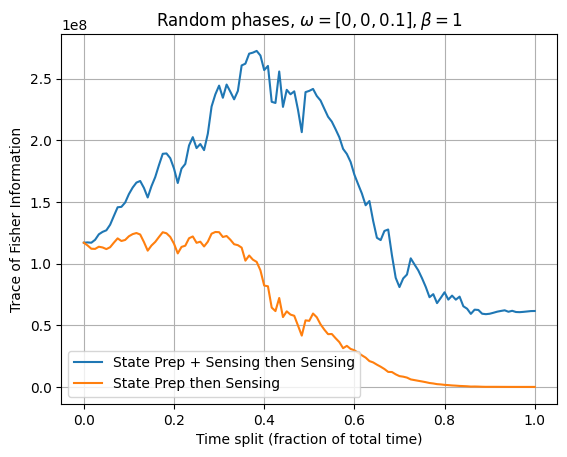

t_split max:  2300
max fisher trace:  272478626.69183934


In [4]:
t_split_plot = [t / t_steps for t in t_split_grid]
plt.plot(t_split_plot, trace_vals_concurrent, label='State Prep + Sensing then Sensing')
plt.plot(t_split_plot, trace_vals_seperate, label='State Prep then Sensing')
plt.xlabel(f'Time split (fraction of total time)')
plt.ylabel('Trace of Fisher Information')
plt.title(f'Random phases, $\omega = {w_true}, \\beta = {beta}$')
plt.legend()
plt.grid()
plt.show()
print("t_split max: ",t_split_grid[np.argmax(trace_vals_concurrent)])
print("max fisher trace: ", np.max(trace_vals_concurrent))

In [144]:
t_split = 0
trace_vals_over_time = []
fisher_evolution_time = np.arange(0, t_steps+1, 10)
beta = 1
phi = 2*np.pi*rng.random(t_steps)
#phi = np.full(t_steps, 3*np.pi/4)
H_c_array = H_c(phi, beta, omega, J)
U_c_array = [expm(-1j * delta_t * H_c_array[i]) for i in range(t_steps)]
U_c_dagger_array = [U_c_array[i].conj().transpose() for i in range(t_steps)]

exp_val_1, dx_1, dy_1, dz_1 = compute_expectations_concurrent_then_sensing(
    w_true, t_split
)

for j in fisher_evolution_time:
    del_expectation_x = dx_1[:j]
    del_expectation_y = dy_1[:j]
    del_expectation_z = dz_1[:j]
    fisher_info = fisher(del_expectation_x, del_expectation_y, del_expectation_z)
    trace_vals_over_time.append(fisher_info[0,0])

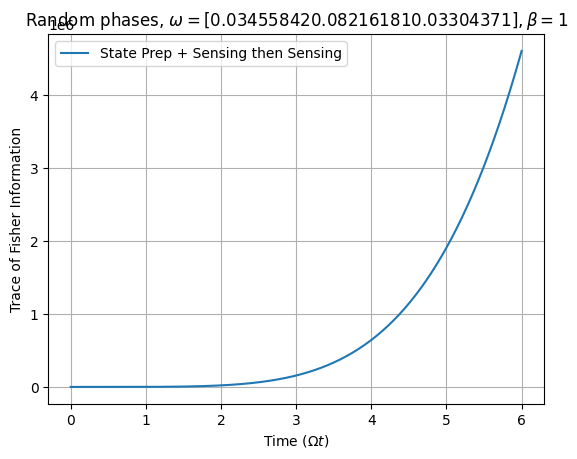

w_true:  [0.03455842 0.08216181 0.03304371]


(array([ 1.84098331e-01, -4.91708928e+02]),
 array([[ 8.53407840e-06, -3.84353291e-02],
        [-3.84353291e-02,  1.84643151e+02]]))

In [148]:
fisher_time_plot = delta_t * fisher_evolution_time
plt.plot(fisher_time_plot, trace_vals_over_time, label='State Prep + Sensing then Sensing')
plt.xlabel(f'Time ($\Omega t$)')
plt.ylabel('Trace of Fisher Information')
plt.title(f'Random phases, $\omega = {w_true}, \\beta = {beta}$')
plt.legend()
plt.grid()
plt.show()
print("w_true: ", w_true)
def linear_fit(x, m, c):
    return m * x + c
def quadratic_fit(x, a, b):
    return a * x**2 + b * x
curve_fit(quadratic_fit, fisher_evolution_time, trace_vals_over_time)

In [ ]:
runs = len(beta_array)
runtime_array = np.zeros(runs)
covar_array = [None] * runs
mean_array = [None] * runs
std_array = [None] * runs
fisher_array = [None] * runs
w_est_all_runs = [None] * runs
w_est_dict_failures = [None] * runs
bias = [None] * runs
CRB_diff_eig = [None] * runs
fisher_shannon_entropy = [None] * runs

for k in range(runs):
    start_time = t.time()
    shannon = []
    w_est = []
    failures = []
    beta = beta_array[k]
    phi = 2*np.pi*rng.random(t_steps)
    H_c_array = H_c(phi, beta, omega, J)
    U_c_array = [expm(-1j * delta_t * H_c_array[i]) for i in range(t_steps)]
    U_c_dagger_array = [U_c_array[i].conj().transpose() for i in range(t_steps)]

    #Calculate expectation value
    expectation, del_expect_x, del_expect_y, del_expect_z = compute_expectations(w_true)
    
    #Calculate fisher information matrix and shannon entropy
    for j in np.arange(0, t_steps+1, 10):
        del_expectation_x = del_expect_x[:j]
        del_expectation_y = del_expect_y[:j]
        del_expectation_z = del_expect_z[:j]
        fisher_matrix = np.zeros((3, 3))
        fisher_matrix[0, 0] = np.vdot(del_expectation_x, del_expectation_x) / sn_sd**2
        fisher_matrix[1, 1] = np.vdot(del_expectation_y, del_expectation_y) / sn_sd**2
        fisher_matrix[2, 2] = np.vdot(del_expectation_z, del_expectation_z) / sn_sd**2
        fisher_matrix[0, 1] = np.vdot(del_expectation_x, del_expectation_y) / sn_sd**2
        fisher_matrix[0, 2] = np.vdot(del_expectation_x, del_expectation_z) / sn_sd**2
        fisher_matrix[1, 2] = np.vdot(del_expectation_y, del_expectation_z) / sn_sd**2
        fisher_matrix[1, 0] = fisher_matrix[0, 1]
        fisher_matrix[2, 0] = fisher_matrix[0, 2]
        fisher_matrix[2, 1] = fisher_matrix[1, 2]
        fisher_eig = np.linalg.eigvals(fisher_matrix)
        fisher_eig = fisher_eig/np.sum(fisher_eig)
        shannon.append(-np.sum(fisher_eig * np.log(fisher_eig)))
    fisher_shannon_entropy[k] = np.array(shannon)
    fisher_array[k] = fisher_matrix

    while(len(w_est) < iter):
        noise = [rng.normal(0, sn_sd, t_steps+1) for _ in range(batch_size)]
        w_est_dict = Parallel(n_jobs=-1)(delayed(w_estimate)(gaussian_noise = n, expectation = expectation, w_init = w_init) for n in noise)
        #failures.extend([res for res in w_est_dict if not res.success])
        successes = [res.x for res in w_est_dict if res.success]
        w_est.extend(successes)
    #w_est_dict_failures[k] = failures
    w_est = np.array(w_est[:iter])
    #w_est_all_runs[k] = w_est

   #Calculate covariance and mean of w estimates
    covariance = np.cov(w_est, rowvar=False)
    covar_array[k] = covariance
    mean_array[k] = np.mean(w_est, axis=0)
    bias[k] = mean_array[k] - np.array(w_true)
    std_array[k] = np.diag(covariance)

    end_time = t.time()
    runtime_array[k] = end_time - start_time
    
fisher_shannon_time = delta_t * np.arange(0, t_steps+1, 10)
fisher_inv_array = np.linalg.inv(fisher_array)
fisher_inv_trace = np.trace(fisher_inv_array, axis1=1, axis2=2)
fisher_inv_normalized = fisher_inv_array / fisher_inv_trace[:, None, None]
cov_array_trace = np.trace(covar_array, axis1=1, axis2=2)
cov_array_normalized = covar_array / cov_array_trace[:, None, None]
infidelity_values = np.array([1-fidelity(fisher_inv_normalized[i], cov_array_normalized[i]) for i in range(runs)])
MSE = np.array([[bias[i][k]**2 + std_array[i][k] for k in range(len(w_true))] for i in range(runs)])

for i in range(runs):
    CRB_diff = covar_array[i] - fisher_inv_array[i]
    CRB_diff_eig[i] = np.linalg.eigvals(CRB_diff)


C:\Users\alexg\AppData\Local\Temp\ipykernel_22416\1805041961.py:92: RuntimeWarning: invalid value encountered in divide
  fisher_eig = fisher_eig/np.sum(fisher_eig)


In [ ]:
#Folder to save data in
folder = "/users/agarcia2001/data_"

parameters = (
    f"Parameters: J = {J}; beta = {beta:.3f}; omega = {omega}; w = {w_true}; sn_sd = {sn_sd:.3f}; "
    f"delta_t = {delta_t}; t_steps = {t_steps}; iter = {iter}; "
    f"Initial state: theta_scs = {theta_scs:.3f}; phi_scs = {phi_scs:.3f}; Initial observable = {obs_0_string}"
)


np.save(f"{folder}/mean_array.npy", mean_array)
np.save(f"{folder}/bias.npy", bias)
np.save(f"{folder}/std_array.npy", std_array)
np.save(f"{folder}/beta_array.npy", beta_array)
np.save(f"{folder}/covar_array.npy", covar_array)
np.save(f"{folder}/fisher.npy", fisher_array)
np.save(f"{folder}/runtime.npy", runtime_array)
#np.save(f"{folder}/w_est_all_runs.npy", np.array(w_est_all_runs))
np.save(f"{folder}/fidelity.npy", infidelity_values)
np.save(f"{folder}/evolution_time.npy", evolution_time)
np.save(f"{folder}/fisher_inv_trace.npy", fisher_inv_trace)
np.save(f"{folder}/covar_trace.npy", cov_array_trace)
np.save(f"{folder}/CRB_diff_eig.npy", CRB_diff_eig)
np.save(f"{folder}/fisher_shannon_entropy.npy", fisher_shannon_entropy)
np.save(f"{folder}/fisher_shannon_time.npy", fisher_shannon_time)
with open(f"{folder}/parameters.txt", "w") as f:
    f.write(parameters)
# with open(f"{folder}/w_est_failures.txt", "w") as f:
#     f.write(str(w_est_dict_failures))



